# Unidade IV — Mineração de Padrões

## Algoritmo Apriori

**Carga estimada:** 3 horas  
**Pré-requisitos:** itemsets, suporte, combinações e Python.

> **Pergunta norteadora:** como evitar testar todas as combinações quando o espaço de busca cresce exponencialmente?


## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- explicar a propriedade antimonótona do suporte;
- descrever geração, poda e contagem de candidatos;
- implementar uma versão didática do Apriori;
- analisar como suporte mínimo altera custo e resultados.


In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid", context="notebook")


In [2]:
transacoes = [
    {"arroz", "feijao", "oleo"}, {"arroz", "feijao"},
    {"arroz", "leite"}, {"pao", "leite", "manteiga"},
    {"pao", "leite"}, {"arroz", "feijao", "oleo"},
    {"pao", "cafe"}, {"arroz", "feijao", "leite"},
    {"pao", "leite", "manteiga"}, {"arroz", "feijao"},
    {"cafe", "leite"}, {"arroz", "feijao", "oleo", "leite"},
]
itens = sorted(set().union(*transacoes))
pd.Series({"transacoes": len(transacoes), "itens_distintos": len(itens), "combinacoes_nao_vazias": 2 ** len(itens) - 1})


transacoes                 12
itens_distintos             7
combinacoes_nao_vazias    127
dtype: int64

## Propriedade antimonótona

Se $X\subseteq Y$, toda transação que contém $Y$ também contém $X$. Portanto,

$$\operatorname{sup}(Y)\leq\operatorname{sup}(X).$$

Se um itemset é infrequente, nenhum de seus supersets pode ser frequente no mesmo limiar. A implicação inversa não vale: subconjuntos frequentes são necessários, mas não garantem que sua união seja frequente.


## Geração e poda

1. Conte itemsets de tamanho 1 e mantenha os frequentes.
2. Una frequentes para gerar candidatos de tamanho $k$.
3. Pode um candidato se algum subconjunto de tamanho $k-1$ for infrequente.
4. Conte os candidatos restantes e repita até não haver novos frequentes.

A implementação abaixo privilegia transparência, não desempenho industrial.


In [3]:
def suporte(itemset: frozenset[str], compras: list[set[str]]) -> float:
    return sum(itemset.issubset(compra) for compra in compras) / len(compras)


def apriori_didatico(
    compras: list[set[str]], min_support: float
) -> tuple[pd.DataFrame, pd.DataFrame]:
    universo = sorted(set().union(*compras))
    nivel = {frozenset([item]) for item in universo}
    frequentes: dict[frozenset[str], float] = {}
    auditoria = []
    k = 1

    while nivel:
        avaliados = {c: suporte(c, compras) for c in nivel}
        nivel_frequente = {c for c, s in avaliados.items() if s >= min_support}
        frequentes.update({c: avaliados[c] for c in nivel_frequente})
        auditoria.append({
            "tamanho": k, "candidatos_avaliados": len(nivel),
            "itemsets_frequentes": len(nivel_frequente),
        })
        k += 1
        candidatos = {
            a | b for a in nivel_frequente for b in nivel_frequente
            if len(a | b) == k
        }
        nivel = {
            candidato for candidato in candidatos
            if all(
                frozenset(subconjunto) in nivel_frequente
                for subconjunto in combinations(candidato, k - 1)
            )
        }

    tabela = pd.DataFrame([
        {"support": s, "itemsets": itemset, "tamanho": len(itemset)}
        for itemset, s in frequentes.items()
    ]).sort_values(["tamanho", "support"], ascending=[True, False])
    return tabela.reset_index(drop=True), pd.DataFrame(auditoria)


In [4]:
frequentes_didaticos, auditoria = apriori_didatico(transacoes, min_support=0.25)
display(auditoria)
frequentes_didaticos


,tamanho,candidatos_avaliados,itemsets_frequentes
0,1,7,5
1,2,10,5
2,3,1,1


,support,itemsets,tamanho
0,0.583333,(leite),1
1,0.583333,(arroz),1
2,0.500000,(feijao),1
3,0.333333,(pao),1
4,0.250000,(oleo),1
5,0.500000,"(feijao, arroz)",2
6,0.250000,"(leite, arroz)",2
7,0.250000,"(leite, pao)",2
8,0.250000,"(oleo, arroz)",2
9,0.250000,"(oleo, feijao)",2


A auditoria mostra quantos candidatos chegam à contagem em cada nível. Quando nenhum frequente de tamanho $k$ permanece, nenhum candidato maior pode sobreviver. A poda evita percorrer a base para supersets que já possuem um subconjunto infrequente.


## Comparação com `mlxtend`

Usaremos a mesma matriz e o mesmo limiar. A verificação compara itemsets e suportes, não apenas o número de linhas.


In [5]:
te = TransactionEncoder()
matriz = te.fit([sorted(t) for t in transacoes]).transform(transacoes)
cestas = pd.DataFrame(matriz, columns=te.columns_)
frequentes_biblioteca = apriori(cestas, min_support=0.25, use_colnames=True)
esperado = dict(zip(frequentes_didaticos["itemsets"], frequentes_didaticos["support"]))
obtido = dict(zip(frequentes_biblioteca["itemsets"], frequentes_biblioteca["support"]))
assert esperado.keys() == obtido.keys()
assert all(abs(esperado[k] - obtido[k]) < 1e-12 for k in esperado)
pd.Series({"itemsets_em_cada_implementacao": len(esperado), "resultados_identicos": True})


itemsets_em_cada_implementacao      11
resultados_identicos              True
dtype: object

## Efeito do suporte mínimo

Reduzir o limiar nunca remove um itemset já frequente, mas pode aumentar rapidamente candidatos, resultados e custo. O gráfico descreve esta base pequena, não o tempo assintótico geral.


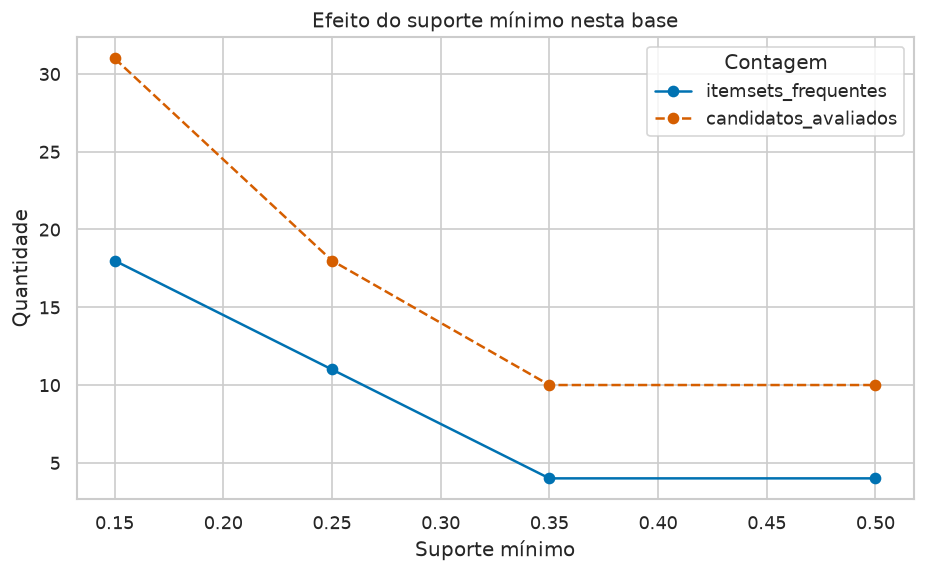

,suporte_minimo,itemsets_frequentes,candidatos_avaliados
0,0.15,18,31
1,0.25,11,18
2,0.35,4,10
3,0.50,4,10


In [6]:
resultados_limiares = []
for limiar in [0.15, 0.25, 0.35, 0.50]:
    frequentes, log = apriori_didatico(transacoes, min_support=limiar)
    resultados_limiares.append({
        "suporte_minimo": limiar, "itemsets_frequentes": len(frequentes),
        "candidatos_avaliados": log["candidatos_avaliados"].sum(),
    })
comparacao = pd.DataFrame(resultados_limiares)
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
comparacao.plot(
    x="suporte_minimo", y=["itemsets_frequentes", "candidatos_avaliados"],
    marker="o", style=["-", "--"], color=["#0072B2", "#D55E00"], ax=ax,
)
ax.set(title="Efeito do suporte mínimo nesta base", xlabel="Suporte mínimo", ylabel="Quantidade")
ax.legend(title="Contagem")
plt.show()
comparacao


O limiar menor amplia a busca e retorna padrões menos prevalentes. A decisão deve considerar tamanho da base, coincidências, capacidade de revisão e relevância de nichos.

> **U04-NB02-V01 — Verifique seu entendimento:** se `{arroz, cafe}` é infrequente, o que podemos concluir sobre `{arroz, cafe, leite}` e por quê?

> **U04-NB02-E01 — Exercício:** acrescente quatro transações, execute as duas implementações com suportes 0,20 e 0,30 e compare itemsets, candidatos avaliados e interpretação. Explique qualquer mudança causada pelo novo denominador.


## Síntese

- O suporte é antimonótono: supersets não podem ser mais frequentes que subconjuntos.
- Apriori alterna geração, poda e contagem por tamanho.
- Implementações devem ser verificadas pelo conteúdo e pelos valores.
- Limiar menor amplia cobertura e custo, sem garantir utilidade.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 4, seção 4.2.
- AGRAWAL, Rakesh; SRIKANT, Ramakrishnan. Fast algorithms for mining association rules. *VLDB*, 1994.
